In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import cv2
from glob import glob

In [10]:
ROOT = r'C:\Users\sahil\PycharmProjects\synthetic_mri_gan'
RAW_DIR = os.path.join(ROOT, 'data', 'raw')
PROCESSED_DIR = os.path.join(ROOT, 'data', 'processed')

print(f"Project root: {ROOT}")
print(f"Raw NIfTI data path: {RAW_DIR}")
print(f"Processed NumPy data path: {PROCESSED_DIR}")

Project root: C:\Users\sahil\PycharmProjects\synthetic_mri_gan
Raw NIfTI data path: C:\Users\sahil\PycharmProjects\synthetic_mri_gan\data\raw
Processed NumPy data path: C:\Users\sahil\PycharmProjects\synthetic_mri_gan\data\processed


In [11]:
subject_dirs = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])
print(f"Found {len(subject_dirs)} raw subjects.")

first_subject_id = subject_dirs[0]
first_subject_path = os.path.join(RAW_DIR, first_subject_id)
print(f"\nInspecting files for subject: {first_subject_id}")
print(os.listdir(first_subject_path))

Found 369 raw subjects.

Inspecting files for subject: BraTS20_Training_001
['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']



T2 Volume Shape: (240, 240, 155)
T1ce Volume Shape: (240, 240, 155)


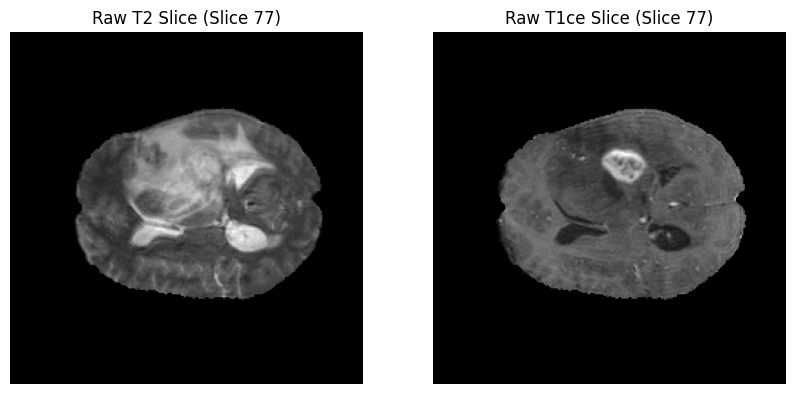

In [12]:
t2_files = glob(os.path.join(first_subject_path, '*t2*.nii'))
t1ce_files = glob(os.path.join(first_subject_path, '*t1ce*.nii'))

if t2_files and t1ce_files:
    t2_vol_nifti = nib.load(t2_files[0])
    t1ce_vol_nifti = nib.load(t1ce_files[0])
    
    t2_vol = t2_vol_nifti.get_fdata()
    t1ce_vol = t1ce_vol_nifti.get_fdata()
    
    print(f"\nT2 Volume Shape: {t2_vol.shape}")
    print(f"T1ce Volume Shape: {t1ce_vol.shape}")
    
    slice_idx = t2_vol.shape[2] // 2
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(t2_vol[:, :, slice_idx], cmap='gray')
    axes[0].set_title(f'Raw T2 Slice (Slice {slice_idx})')
    axes[0].axis('off')

    axes[1].imshow(t1ce_vol[:, :, slice_idx], cmap='gray')
    axes[1].set_title(f'Raw T1ce Slice (Slice {slice_idx})')
    axes[1].axis('off')
    
    plt.show()
else:
    print("Could not find T2 and T1ce files for the first subject.")

Processed file shape: (155, 2, 256, 256)
T2 slice min/max: -1.00 / 1.00


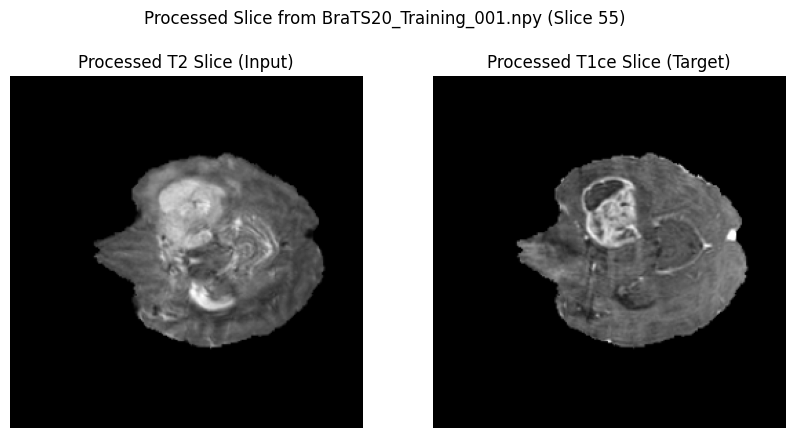

In [13]:
npy_files = sorted(glob(os.path.join(PROCESSED_DIR, '*.npy')))

if not npy_files:
    print("No processed .npy files found. Run 'python src/preprocess.py' first.")
else:
    first_npy_path = npy_files[0]
    processed_data = np.load(first_npy_path)
    
    print(f"Processed file shape: {processed_data.shape}")
    
    num_slices = processed_data.shape[0]
    random_slice_idx = np.random.randint(0, num_slices)
    
    t2_slice = processed_data[random_slice_idx, 0, :, :]
    t1ce_slice = processed_data[random_slice_idx, 1, :, :]
    
    # Check normalization range
    print(f"T2 slice min/max: {t2_slice.min():.2f} / {t2_slice.max():.2f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(t2_slice, cmap='gray')
    axes[0].set_title(f'Processed T2 Slice (Input)')
    axes[0].axis('off')

    axes[1].imshow(t1ce_slice, cmap='gray')
    axes[1].set_title(f'Processed T1ce Slice (Target)')
    axes[1].axis('off')
    
    plt.suptitle(f"Processed Slice from {os.path.basename(first_npy_path)} (Slice {random_slice_idx})")
    plt.show()

In [14]:
# Sine Wave (time domain) → checks basic array + plotting functionality.

# FFT Magnitude (frequency domain) → shows my environment can do signal transformations, which are building blocks for:

# image processing (filters, denoising),

# medical image reconstruction,

# audio/signal analysis,

# feature extraction before ML/DL.

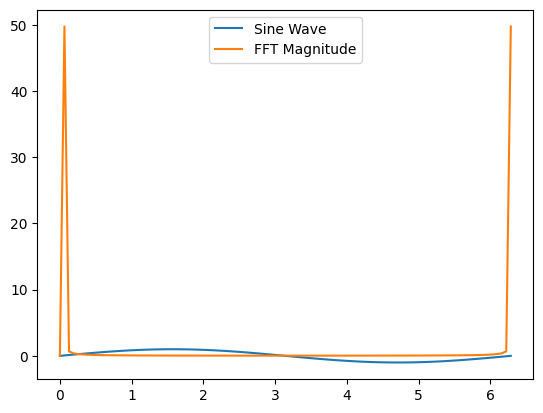

In [15]:
import numpy as np
from scipy.fft import fft

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

yf = fft(y)

plt.plot(x, y, label="Sine Wave")
plt.plot(x, np.abs(yf), label="FFT Magnitude")
plt.legend()
plt.show()